In [1]:
import torchvision
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import io
from PIL import Image


device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


In [ ]:
mnist_train = torchvision.datasets.MNIST(root="/Users/loganfoster/projects/ML/AutoEncoders/MNIST", train = True, download=True, transform=transforms.ToTensor())
mnist_test = torchvision.datasets.MNIST(root="/Users/loganfoster/projects/ML/AutoEncoders/MNIST", train = False, download=True, transform=transforms.ToTensor())

NameError: name 'v2' is not defined

In [3]:
BATCH_SIZE = 256
GRID_SIZE = 8  # Number of images per row/column in the visualization grid

train_loader = torch.utils.data.DataLoader(
    mnist_train,
    batch_size= BATCH_SIZE,
)
test_loader = torch.utils.data.DataLoader(
    mnist_test,
    batch_size= BATCH_SIZE,
)

In [4]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.flatten = nn.Flatten()
        self.first_hidden = nn.Linear(input_dim, hidden_dim)
        self.second_hidden = nn.Linear(hidden_dim, hidden_dim)
        self.mean = nn.Linear(hidden_dim, latent_dim)
        self.var = nn.Linear(hidden_dim, latent_dim)
        self.activation = nn.LeakyReLU()

    def forward(self, x):
        y_ = self.flatten(x)
        y_ = self.first_hidden(y_)
        y = self.activation(y_)
        y_ = self.second_hidden(y)
        y = self.activation(y_)
        mean = self.mean(y)
        log_var = self.var(y)
        return mean, log_var
    
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.first_hidden = nn.Linear(latent_dim, hidden_dim)
        self.second_hidden = nn.Linear(hidden_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)
        self.activation = nn.LeakyReLU()
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        y_ = self.first_hidden(x)
        y_ = self.activation(y_)
        y_ = self.second_hidden(y_)
        y_ = self.activation(y_)
        y_ = self.output(y_)
        y = self.sigmoid(y_)
        return y
    
class VAE(nn.Module):
    def __init__(self, Encoder, Decoder):
        super(VAE, self).__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder
    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var).to(device)
        z = mean + epsilon * var
        return z
    def forward(self, x):
        mean, log_var = self.Encoder(x)
        z = self.reparameterization(mean, torch.exp(log_var / 2))
        reconstruction = self.Decoder(z)
        return reconstruction, mean, log_var
    

In [5]:
def KL_latent_loss(mean, log_var):
    # Sum over latent dims, mean over batch — matches BCELoss(reduction="mean")
    return -0.5 * torch.sum(torch.sum(1 + log_var - torch.exp(log_var) - mean**2, dim=1))

Epoch 25/25
Test Error: 
 Avg loss: 26038.008313


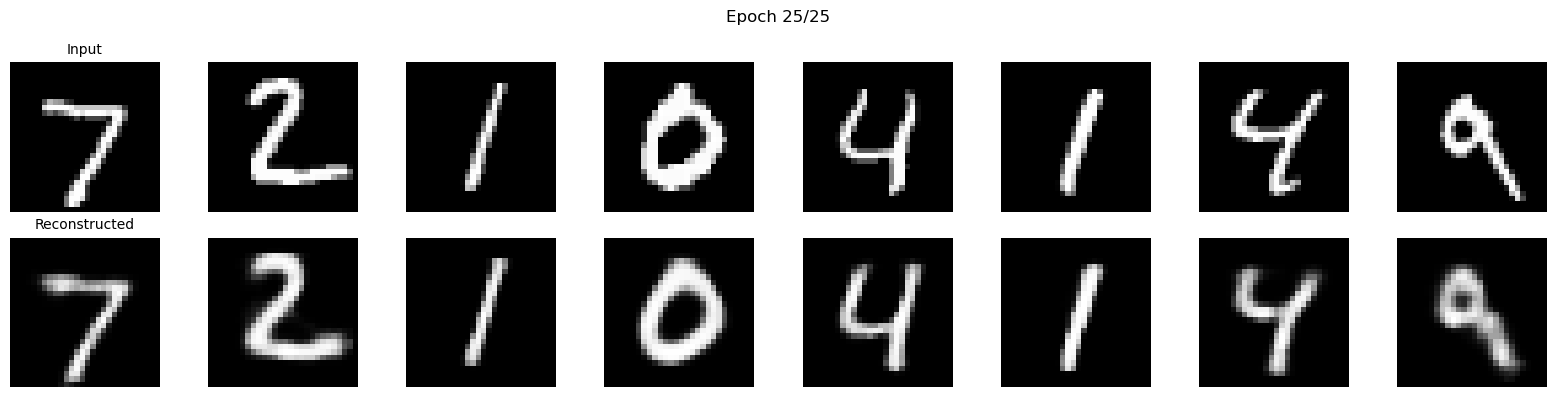

Saved: reconstruction_progress.gif


In [6]:
EPOCHS = 25

INPUT_SIZE = 28 * 28
HIDDEN_SIZE = 300
LATENT_DIM = 10

encoder = Encoder(INPUT_SIZE, HIDDEN_SIZE, LATENT_DIM)
decoder = Decoder(LATENT_DIM, HIDDEN_SIZE, INPUT_SIZE)
model = VAE(encoder, decoder).to(device)


optimizer = torch.optim.Adam([
        {"params": encoder.parameters(), "name": "encoder"},
        {"params": decoder.parameters(), "name": "decoder"}
    ],
    lr = 0.001,
    weight_decay = 1e-5)
reconstr_loss = torch.nn.BCELoss(reduction="sum")

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

lrs = []
test_losses = []
frames = []

for epoch in range(EPOCHS):

    model.train()

    epoch_loss = 0
    for batch, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        prediction, mean, log_var = model(images)
        kl_loss = KL_latent_loss(mean, log_var) 
        prediction = prediction.reshape(images.size(0), 1, 28, 28)
        recon_loss = reconstr_loss(prediction, images)
        loss = recon_loss + kl_loss

        epoch_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss_val, current = loss.item(), batch * BATCH_SIZE + len(images)
            print(f"loss: {loss_val:>7f}  [{current:>5d}/{len(train_loader.dataset):>5d}]")

    # Step scheduler once per epoch
    scheduler.step(epoch_loss / len(train_loader))

    # save model

    torch.save(model.state_dict(), "full_VAE.pth")


    with torch.no_grad():
        test_loss = 0
        model.eval()
        for images, labels in test_loader:
            images = images.to(device) 
            prediction, mean, log_var = model(images)
            kl_loss = KL_latent_loss(mean, log_var) 
            prediction = prediction.reshape(images.size(0), 1, 28, 28)
            recon_loss = reconstr_loss(prediction, images)
            loss = recon_loss + kl_loss 
            
            test_loss += loss.item()
            

        test_loss /= len(test_loader)

        test_losses.append(test_loss)

        # clear previous output
        clear_output(wait=True)

        print(f"Epoch {epoch+1}/{EPOCHS}")
        print(f"Test Error: \n Avg loss: {test_loss:>8f}")

        # Visualize input vs reconstructed images
        sample_images, _ = next(iter(test_loader))
        sample_images = sample_images[:GRID_SIZE * GRID_SIZE]
        sample_images = sample_images.to(device) 
        reconstructed, _, _ = model(sample_images)
        reconstructed = reconstructed.view(-1, 28, 28) * 255.0
        
        input_images = sample_images.squeeze(1)
        
        fig, axes = plt.subplots(2, GRID_SIZE, figsize=(GRID_SIZE * 2, 4))
        
        for i in range(GRID_SIZE):
            axes[0, i].imshow(input_images[i].cpu().numpy(), cmap='gray')
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_title('Input', fontsize=10)
        
        for i in range(GRID_SIZE):
            axes[1, i].imshow(reconstructed[i].cpu().numpy(), cmap='gray')
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_title('Reconstructed', fontsize=10)
        
        fig.suptitle(f'Epoch {epoch+1}/{EPOCHS}', fontsize=12)
        plt.tight_layout()

        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight')
        buf.seek(0)
        frames.append(Image.open(buf).copy())
        buf.close()

        plt.show()

# Save GIF
if frames:
    frames[0].save(
        'reconstruction_progress.gif',
        save_all=True,
        append_images=frames[1:],
        duration=100,
        loop=0
    )
    print("Saved: reconstruction_progress.gif")

Saved: training_metrics_tsne.png


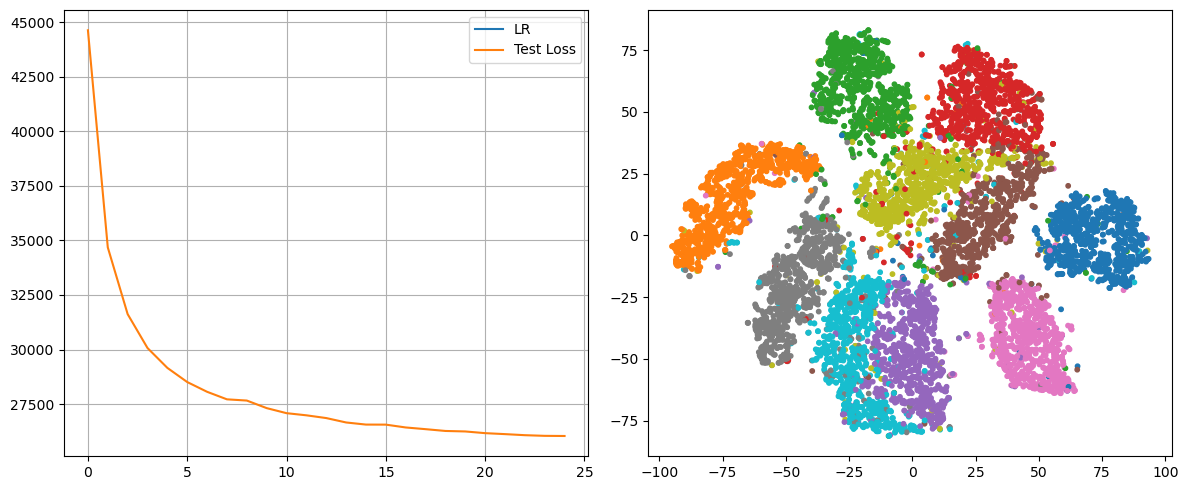

In [7]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(lrs, label="LR")
axes[0].plot(test_losses, label="Test Loss")
axes[0].grid(True)
axes[0].legend()



with torch.no_grad():
    reconstructed, _, _ = model(mnist_test.data.float().to(device) / 255.0)
    decoded = reconstructed.view(reconstructed.size(0), -1)  # flatten if needed

decoded_np = decoded.cpu().numpy()

tsne = TSNE()
X_test_2D = tsne.fit_transform(decoded_np)

axes[1].scatter(
    X_test_2D[:, 0],
    X_test_2D[:, 1],
    c=mnist_test.targets.numpy(),
    s=10,
    cmap="tab10"
)

plt.tight_layout()
plt.savefig('training_metrics_tsne_no_Sparse.png', dpi=300, bbox_inches='tight')
print("Saved: training_metrics_tsne.png")
plt.show()


Saved: tsne_with_samples.png


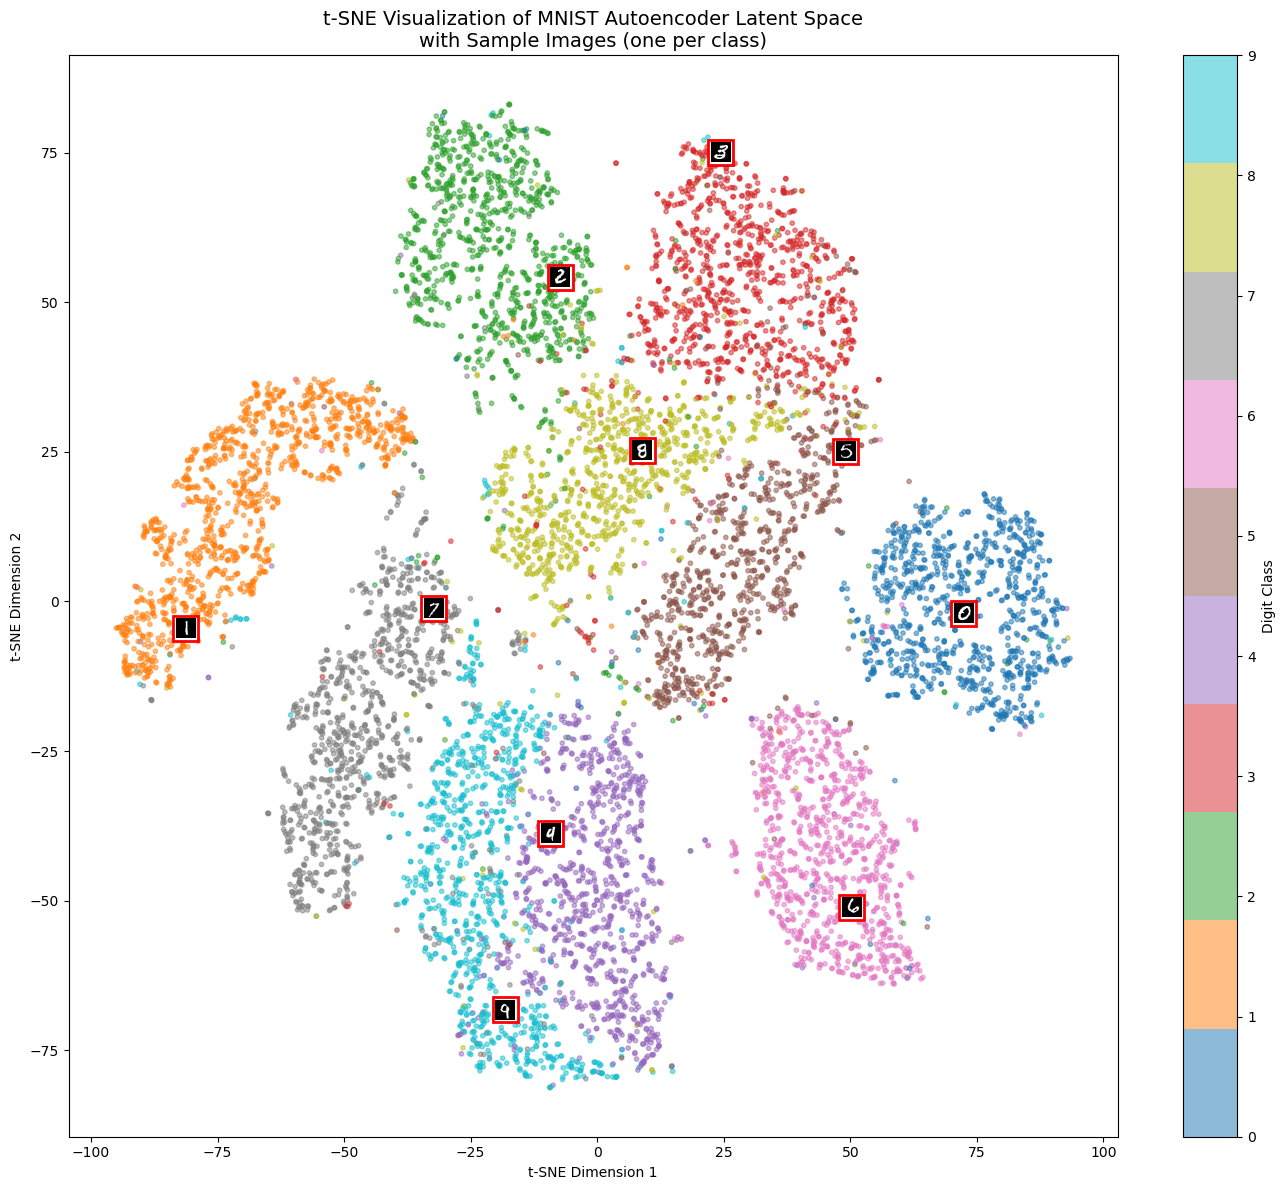

In [8]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Create the scatter plot
fig, ax = plt.subplots(figsize=(14, 12))

# Plot all points as background
ax.scatter(
    X_test_2D[:, 0],
    X_test_2D[:, 1],
    c=mnist_test.targets.numpy(),
    s=10,
    cmap="tab10",
    alpha=0.5
)

# Select one sample from each class
samples_to_plot = []
for digit in range(10):
    # Find indices where the label equals the current digit
    indices = np.where(mnist_test.targets.numpy() == digit)[0]
    # Select a sample from the middle of the cluster (could also be random)
    idx = indices[len(indices) // 2]  # Choose middle sample
    samples_to_plot.append(idx)

# Overlay images on the plot
for idx in samples_to_plot:
    # Get the image
    img = mnist_test.data[idx].numpy()
    
    # Get the 2D coordinates
    x, y = X_test_2D[idx, 0], X_test_2D[idx, 1]
    
    # Create an OffsetImage with the digit
    imagebox = OffsetImage(img, zoom=0.5, cmap='gray')
    imagebox.image.axes = ax
    
    # Create an AnnotationBbox to place the image at the correct position
    ab = AnnotationBbox(imagebox, (x, y),
                        frameon=True,
                        pad=0.2,
                        bboxprops=dict(edgecolor='red', linewidth=2, facecolor='white'))
    
    ax.add_artist(ab)

ax.set_title('t-SNE Visualization of MNIST Autoencoder Latent Space\nwith Sample Images (one per class)', fontsize=14)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')

# Add colorbar
cbar = plt.colorbar(ax.collections[0], ax=ax, ticks=range(10))
cbar.set_label('Digit Class')

plt.tight_layout()
plt.savefig('tsne_with_samples_no_sparse.png', dpi=300, bbox_inches='tight')
print("Saved: tsne_with_samples.png")
plt.show()

In [9]:
twos_tensor_images =  mnist_train.data[mnist_train.targets == 2] / 255.0
sixes_tensor_images =  mnist_train.data[mnist_train.targets == 6] / 255.0

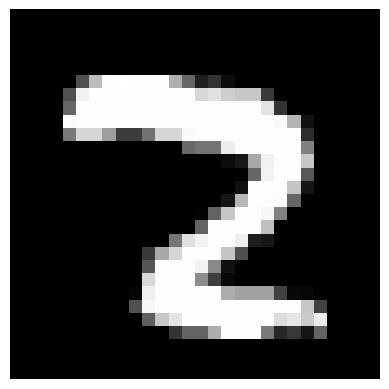

In [11]:
def plot_grayscale_tensor(x: torch.Tensor):
    """
    Accepts shapes:
      (H, W)
      (1, H, W)
      (N, 1, H, W)  -> plots first image
    """

    if x.ndim == 4:      # (N,1,H,W)
        x = x[0]
    if x.ndim == 3:      # (1,H,W)
        x = x.squeeze(0)

    x = x.detach().cpu()

    if x.dtype != torch.uint8:
        x = x.float().clamp(0, 1)

    plt.imshow(x, cmap="gray")
    plt.axis("off")
    plt.show()

plot_grayscale_tensor(twos_tensor_images[3])

In [12]:
_, mean_twos, log_var_twos = model(twos_tensor_images.to(device))
_, mean_sixes, log_var_sixes = model(sixes_tensor_images.to(device))

In [ ]:
print(torch.mean(torch.norm(mean_twos, dim= 1)))
print(torch.mean(torch.norm(log_var_twos, dim= 1)))

tensor(3.3429, device='mps:0', grad_fn=<MeanBackward0>)
tensor(12.3233, device='mps:0', grad_fn=<MeanBackward0>)


In [27]:
import sklearn
twos_mean_cluserting = sklearn.cluster.KMeans(10, n_init= 20).fit(mean_twos.cpu().detach().numpy())
twos_log_var_clustering = sklearn.cluster.KMeans(10, n_init= 20).fit(log_var_twos.cpu().detach().numpy())
two_means_centers = twos_mean_cluserting.cluster_centers_
twos_log_var_centers = twos_log_var_clustering.cluster_centers_


In [31]:
average_two_mean = mean_twos.mean(dim=0)
average_two_log_var = log_var_twos.mean(dim=0)
average_six_mean = mean_sixes.mean(dim=0)
average_six_log_var = log_var_sixes.mean(dim=0)

In [226]:
N = 100
sampled_twos = average_two_mean.unsqueeze(0) + torch.exp(0.5 * average_two_log_var).unsqueeze(0) * torch.randn(N, *average_two_log_var.shape, device=average_two_log_var.device)
sampled_twos.shape

torch.Size([100, 10])

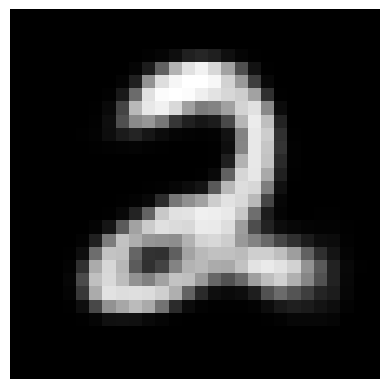

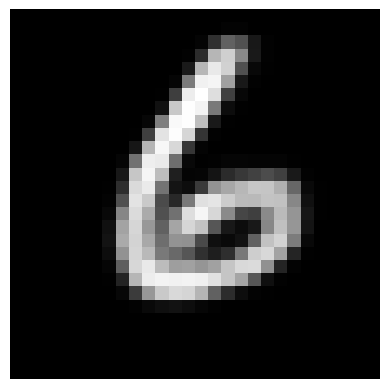

In [220]:
average_two_reconstruction = model.Decoder((average_two_mean+ torch.exp(0.5 * average_two_log_var) * torch.randn_like(average_two_mean)).unsqueeze(0)).view(28, 28).cpu().detach()
average_six_reconstruction = model.Decoder(average_six_mean.unsqueeze(0)).view(28, 28).cpu().detach()
plot_grayscale_tensor(average_two_reconstruction)
plot_grayscale_tensor(average_six_reconstruction)

In [92]:
interpolated_mean, interpolated_log_var = (average_two_mean + average_six_mean) / 2 , (average_two_log_var + average_six_log_var) / 2

In [93]:
six_two_interpolation_reconstruction = model.Decoder(interpolated_mean.unsqueeze(0)).view(28, 28).cpu().detach()

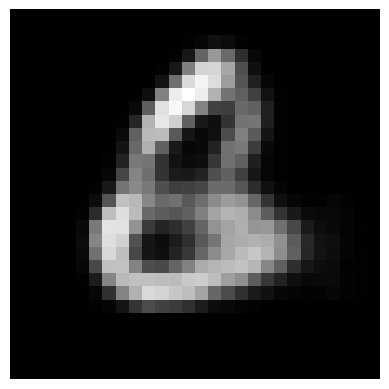

In [17]:
plot_grayscale_tensor(six_two_interpolation_reconstruction)

In [3]:
import torch
import torch.nn as nn

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

classifier = nn.Sequential(
    nn.Conv2d(1, 128, kernel_size=5, stride=1, padding=1),
    nn.Dropout(0.2),
    nn.ReLU(),
    nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
    nn.Dropout(0.2),
    nn.Flatten(),
    nn.Linear(64 * 676, 10),
    #nn.Softmax(dim=1)
).to(device)

classifier.load_state_dict(torch.load("/Users/loganfoster/projects/ML/mnist_classifier/mnist_classifier.pth"))

Using mps device


<All keys matched successfully>

In [4]:
preds = nn.Softmax(dim=1)(classifier(six_two_interpolation_reconstruction.unsqueeze(0).unsqueeze(0).to(device)))

NameError: name 'six_two_interpolation_reconstruction' is not defined

In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def display_blue_grid(tensor: torch.Tensor):
    """Display an N x 10 tensor as a grid of blue squares with opacity = value."""
    N, cols = tensor.shape
    assert cols == 10, "Tensor must have exactly 10 columns"

    fig, ax = plt.subplots(figsize=(cols, N))
    ax.set_xlim(0, cols)
    ax.set_ylim(0, N)
    ax.set_aspect("equal")
    ax.axis("off")

    for row in range(N):
        for col in range(10):
            opacity = tensor[row, col].item()
            rect = patches.Rectangle(
                (col, N - row - 1),  # bottom-left corner (flip so row 0 is at top)
                1, 1,
                linewidth=0.5,
                edgecolor="gray",
                facecolor=(0, 0, 1, opacity),  # RGBA blue with opacity
            )
            ax.add_patch(rect)

    plt.tight_layout()
    plt.show()

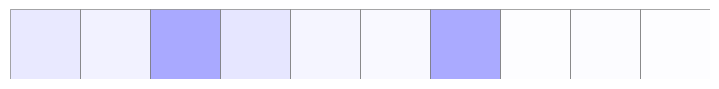

In [41]:
display_blue_grid(preds)

In [228]:
torch.mps.empty_cache()